In [16]:
#Reading out data and preprocesing
import scipy.io
data = scipy.io.loadmat('210921.mat')

spks = data['spks']
tc = data['tc']
cue = data['cueAng']
cueIdx = data['cueAngIdx']
corr = data['isCorr']

#print(spks.shape)
#print(tc.shape)
#print(cue.shape)
#print(cueIdx.shape)
#print(corr.shape)

corr = corr.flatten()
cueIdx = cueIdx.flatten()
#print(cueIdx.shape)
#print(corr.shape)
corr_bool = corr == 1
#print(corr_bool)

spks = spks[corr_bool]
cueIdx = cueIdx[corr_bool]
#print(spks.shape, cueIdx.shape)

In [17]:
#Discriminate cue to opposite cue
import numpy as np
#print(np.unique(cue))
target_cue = 4
opp_cue = 8

in48 = np.isin(cueIdx, [target_cue, opp_cue])
spks_48 = spks[in48]
cue_48 = cueIdx[in48]
#print(spks_48.shape, cue_48.shape)

y = (cue_48 == target_cue).astype(int) #Correct y
#print(y)

In [24]:
n_trials, n_time, n_neurons = spks_48.shape
new_time = n_time // 10
#To 10ms
spks_trim = spks_48[:, :new_time*10, :]

# Reshape 
spks_binned = spks_trim.reshape(n_trials, new_time, 10, n_neurons).sum(axis=2)

window = 10  # 100 ms
boxcar_kernel = np.ones(window) / window

spks_smooth = np.zeros_like(spks_binned)

for trial in range(n_trials):
    for neuron in range(n_neurons):
        spks_smooth[trial, :, neuron] = np.convolve(spks_binned[trial, :, neuron], boxcar_kernel, mode='same')


In [19]:
#Caculate z-score
z_score = np.zeros_like(spks_smooth)

for t in range(spks_smooth.shape[1]):
    mean = spks_smooth[:, t, :].mean(axis=0)
    std = spks_smooth[:, t, :].std(axis=0)
    z_score[:, t, :] = (spks_smooth[:, t, :] - mean) / (std + 1e-10) 

#print(z_score.shape)


In [20]:
from sklearn.linear_model import LogisticRegression

n_trials = spks_smooth.shape[0]
n_time = spks_smooth.shape[1]
#print(n_time, n_trials)

confidence = np.zeros((n_trials, n_time)) #Empty list to store

for t in range(n_time):

    z_score_t = z_score[:, t, :] 

    for i in range(n_trials):
        #Train data
        one_out = np.arange(n_trials) != i
        x_train = z_score_t[one_out]
        y_train = y[one_out]

        #Test data
        x_test = z_score_t[i].reshape(1, -1)
        y_test = y[i]
  
        
        model = LogisticRegression(solver='liblinear')
        model.fit(x_train, y_train)

        y_pred = model.predict_proba(x_test)[0]

        confidence[i, t] = y_pred[y_test]
print(confidence)

[[0.45471727 0.45464523 0.46171386 ... 0.61310835 0.59156761 0.52573471]
 [0.53702124 0.53709274 0.94479735 ... 0.81880909 0.60891849 0.4643458 ]
 [0.45471727 0.45464523 0.46171386 ... 0.61310835 0.59156761 0.52573471]
 ...
 [0.53702124 0.53709274 0.52988894 ... 0.96456936 0.85141782 0.11559703]
 [0.45471727 0.45464523 0.46171386 ... 0.61310835 0.59156761 0.52573471]
 [0.45471727 0.45464523 0.46171386 ... 0.61310835 0.59156761 0.52573471]]


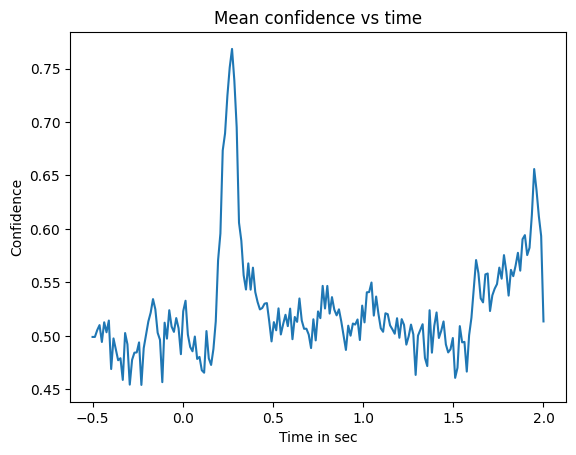

In [21]:
import matplotlib.pyplot as plt

time = np.linspace(-0.5, 2.0, n_time)

plt.figure()
plt.plot(time, confidence.mean(axis=0))
plt.xlabel("Time in sec")
plt.ylabel("Confidence")
plt.title("Mean confidence vs time")
plt.show()

In [46]:
from sklearn.model_selection import train_test_split
n_trials = spks_smooth.shape[0]
n_time = spks_smooth.shape[1]
#print(n_time, n_trials)

confidence2 = np.full((n_trials, n_time), np.nan)

for t in range(n_time):

    X2 = z_score[:, t, :]  

    X_train2, X_test2, y_train2, y_test2, idx_train2, idx_test2 = train_test_split(
        X2,
        y,
        np.arange(n_trials),
        test_size=0.3,
        stratify=y,
        random_state = 0
    )

    model = LogisticRegression(solver='liblinear')
    model.fit(X_train2, y_train2)

    y_pred2 = model.predict_proba(X_test2)

    for j, trial_index in enumerate(idx_test2):
        confidence2[trial_index, t] = y_pred2[j, y_test2[j]]

print(confidence2)

[[0.45373068 0.45362926 0.45829693 ... 0.62765748 0.59807141 0.53809592]
 [0.54626932 0.54637074 0.94526153 ... 0.66036723 0.66085284 0.46190408]
 [0.45373068 0.45362926 0.45829693 ... 0.62765748 0.59807141 0.53809592]
 ...
 [       nan        nan        nan ...        nan        nan        nan]
 [0.45373068 0.45362926 0.45829693 ... 0.62765748 0.59807141 0.53809592]
 [       nan        nan        nan ...        nan        nan        nan]]


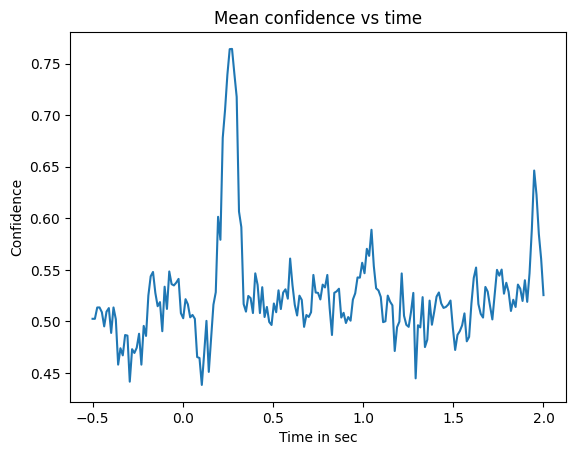

In [47]:
import matplotlib.pyplot as plt

time = np.linspace(-0.5, 2.0, n_time)

plt.figure()
plt.plot(time, np.nanmean(confidence2, axis=0))
plt.xlabel("Time in sec")
plt.ylabel("Confidence")
plt.title("Mean confidence vs time")
plt.show()